# MiniProject1 Proposal: Word Use in the Classic Fantasy

## Question
I want to  find whether fantasy books written by the same author have mostly same word-frequency patterns than the  ones written by different authors. I also want to find words that L. Frank Baum uses more frequently than Lewis Carroll, and following that, I also want to find words that Carroll uses more frequently than Baum.

## Data Sources
I will use four public-domain fantasy books from the Project Gutenberg:

- L. Frank Baum, *The Wonderful Wizard of Oz*: https://www.gutenberg.org/ebooks/55
- L. Frank Baum, *The Marvelous Land of Oz*: https://www.gutenberg.org/ebooks/54
- Lewis Carroll, *Alice's Adventures in Wonderland*: https://www.gutenberg.org/ebooks/11
- Lewis Carroll, *Through the Looking-Glass*: https://www.gutenberg.org/ebooks/12

## Approach
I will first download the plain-text versions of the books, and then convert the text to lowercase, and then separate it into words, and remove punctuatin. Following that,  I will then count the remaining words. I will compare the two books by Baum, then compare the two books by Carroll, and finally compare the two authors. Because the books have different and varied lengths, I will use normalized frequencies, such as similar occurrences per 50000 to 10,000 words. I will then create bar charts showing me the common words and then words with the largest differences between the authors.

## Potential Problems

Potential problems could be things such as character names, difference in  book lengths, and also the fact that differences between British and American English may also affect the results. 

# Written text as operational data

Written text is one type of data

### Why people write?

 - To communicate: their thoughts, feelings, urgency, needs, information

### Why people communicate?

1. To express emotions
1. To share information
1. To enable or elicit an action
1. ...

### We will use written text for the purpose other than 
1. To experience emotion
1. To learn something the author intended us to learn
1. To do what the author intended us to do

### Instead, we will use written text to recognize who wrote it
 - By calculating and comparing word frequencies in written documents
 
See, for example, likely fictional story https://medium.com/@amuse/how-the-nsa-caught-satoshi-nakamoto-868affcef595

### Example 1. Dictionaries in python (associative arrays)

Plot the frequency distribution of words on a web page.

In [5]:
import requests, re
# re is a module for regular expressions: to detect various combinations of characters
import operator

# Start from a simple document
r = requests .get('http://eecs.utk.edu')

# What comes back includes headers and other HTTP stuff, get just the body of the response
t = r.text

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf[w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

class="menu-item	54
<div	54
menu-item-object-page	45
menu-item-type-post_type	45
of	39
</div>	38
<td	36
</td>	35
<li><a	35
class="eventless">	28
<link	25
<script	24
/>	21
</ul>	21


### Example 2

Lots of markup in the output, lets remove it --- 

use BeautifulSoup and nltk modules and practice some regular expressions.

In [12]:
import requests, re, nltk
from bs4 import BeautifulSoup
from nltk import clean_html
from collections import Counter
import operator

# we may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

# We most likely would like to remove html markup
def cleanHtml (html):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, 'html.parser')
    return soup .get_text()

# We also want to remove special characters, quotes, etc. from each word
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)
       
# define a function to get text/clean/calculate frequency
def get_wf (URL):
    # first get the web page
    r = requests .get(URL)
    
    # Now clean
    # remove html markup
    t = cleanHtml (r .text) .lower()
    
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re .split('\s+',t)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter (wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf. pop(k, None)
        
    #how many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
        
    
    # Get ordered list
    wfs = sorted (wf .items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs [ 0:ml ] [::-1], tw)
        
# Now populate two lists    
(wf_ee, tw_ee) = get_wf('http://www.gutenberg.org/ebooks/1342.txt.utf-8')
(wf_bu, tw_bu) = get_wf('http://www.gutenberg.org/ebooks/76.txt.utf-8')

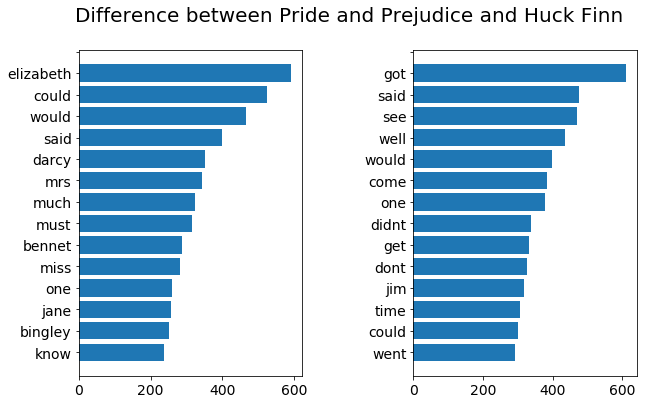

In [14]:
#Plot the results: are there striking differences in language?
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_ee)+1) 
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    pylab .yticks (pos, [ x [0] for x in wf_ee ])
    ax1 .barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_bu)+1) 
    pylab .yticks (pos, [ x [0] for x in wf_bu ])
    ax2 .barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists (wf_ee, wf_bu, 'Difference between Pride and Prejudice and Huck Finn')

In [9]:
#In case Project gutenberg is blocked you can download text to your laptop and copy to the docker container via scp
#Assuming the file name you copy is pg4680.txt here is how you change the script
# Please note the option errors='replace'
# without it python invariably runs into unicode errors
f = open ('pg4680.txt', 'r', encoding="ascii", errors='replace')
    
# What comes back includes headers and other HTTP stuff, get just the body of the response
t = f.read()

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf [w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

and	2836
of	2676
to	2646
a	2217
in	1422
his	1205
he	928
that	920
was	823
for	798
with	797
as	672
I	505
you	497


# Assignment 1

1. Compare word frequencies between two works of a single author.
1. Compare word frequencies between works of two authors.
1. Are there some words preferred by one author but used less frequently by another author?

Extra credit

1. The frequency of a specific word, e.g., "would" should follow a binomial distribution (each regular word in a document is a trial and with probability p that word is "would". The estimate for p is N("would")/N(regular word)). Do these binomial distributions for your chosen word differ significantly between books of the same author or between authors? 

Project Gutenberg is a good source of for fiction and non-fiction.

E.g below are two most popular books from Project Gutenberg:
- Pride and Prejudice at http://www.gutenberg.org/ebooks/1342.txt.utf-8
- Adventures of Huckleberry Finn at http://www.gutenberg.org/ebooks/76.txt.utf-8

In [18]:
import requests, re, nltk
#In case your text is not on Project Gutenberg but at some other URL
#http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter2.html
# that contains 12 parts
t = ""
for i in range(2,13):
  r = requests .get('http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter' + str(i) + '.html')
  t = t + r.text

In [23]:
len(t)

1323653

## Data check

,Author,Total words,Filtered words,Unique filtered words
Book,,,,
Wonderful Wizard of Oz,L. Frank Baum,39767,16912,2800
Marvelous Land of Oz,L. Frank Baum,42402,19472,4227
Alice in Wonderland,Lewis Carroll,26776,11381,2444
Through the Looking-Glass,Lewis Carroll,30153,13148,2698


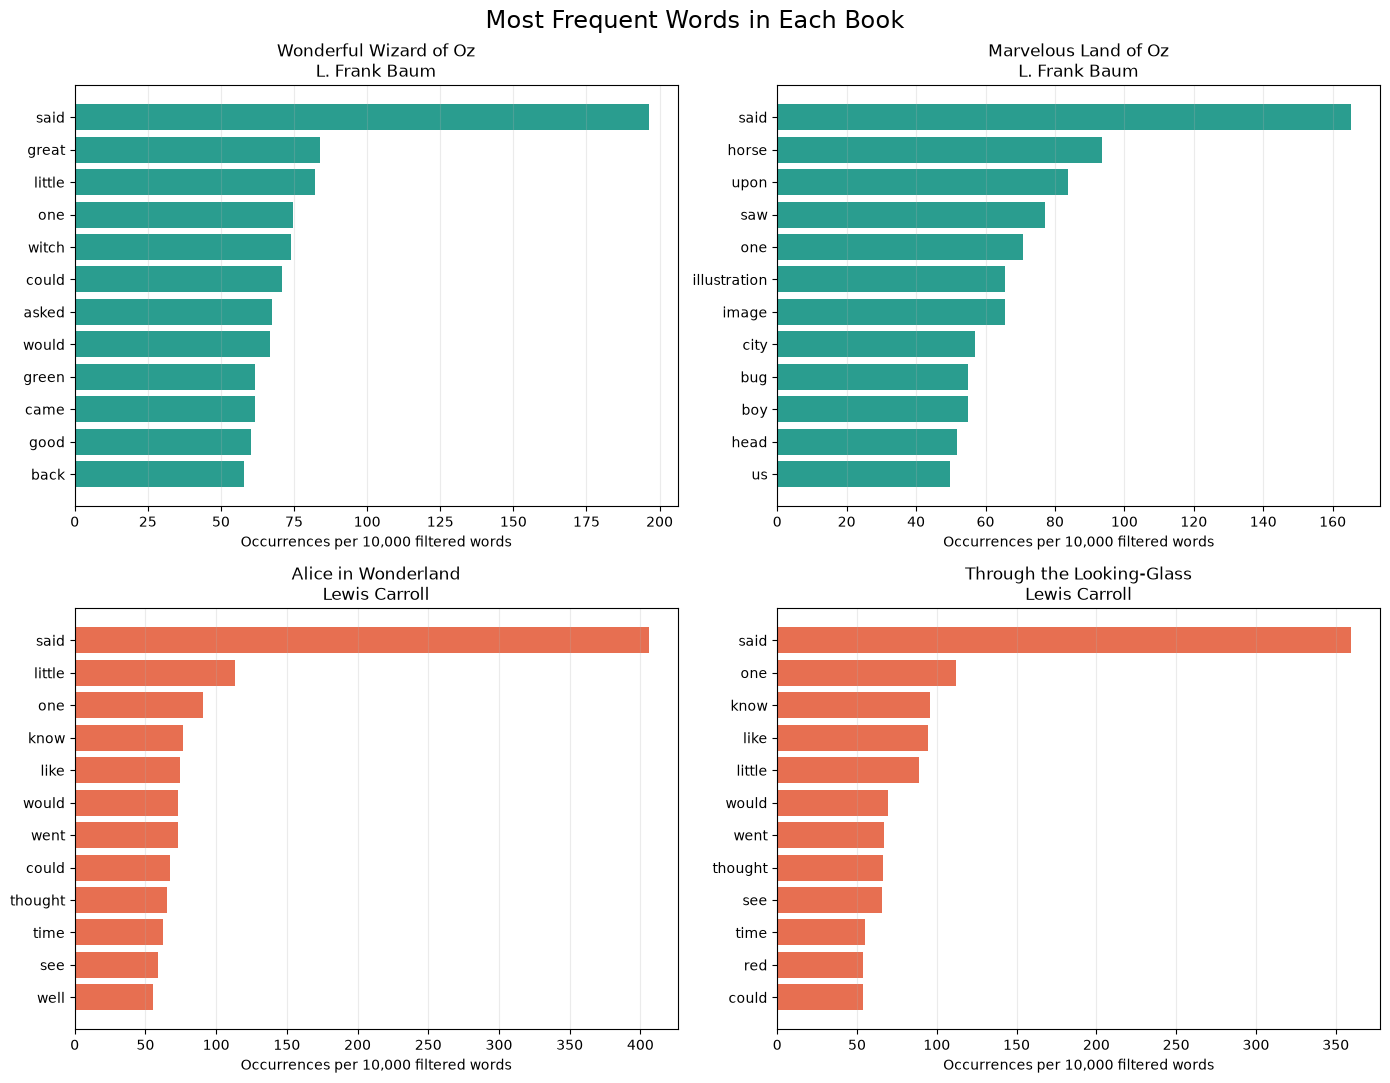

## Similarity of complete word-frequency patterns

,Wonderful Wizard of Oz,Marvelous Land of Oz,Alice in Wonderland,Through the Looking-Glass
Wonderful Wizard of Oz,1.000,0.758,0.735,0.735
Marvelous Land of Oz,0.758,1.000,0.666,0.665
Alice in Wonderland,0.735,0.666,1.000,0.941
Through the Looking-Glass,0.735,0.665,0.941,1.000


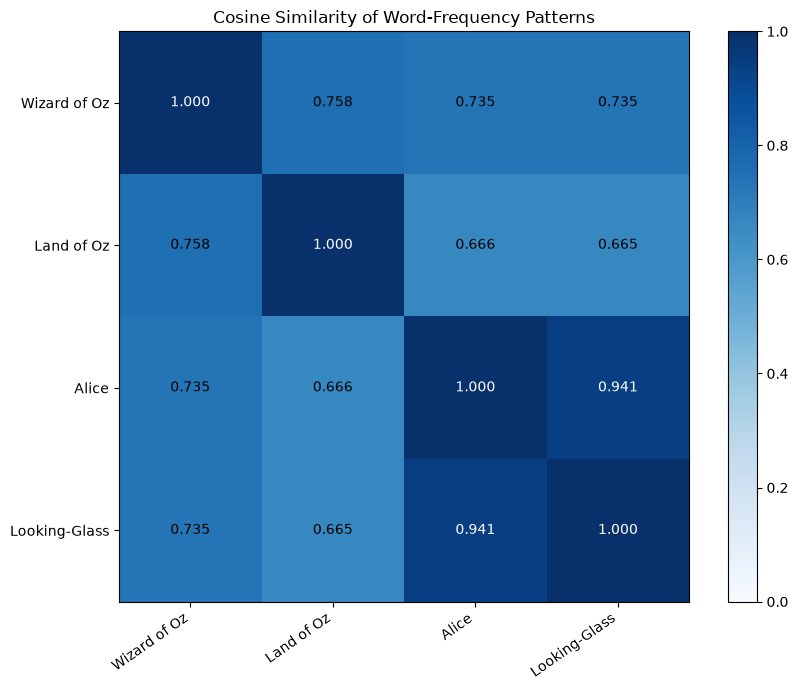

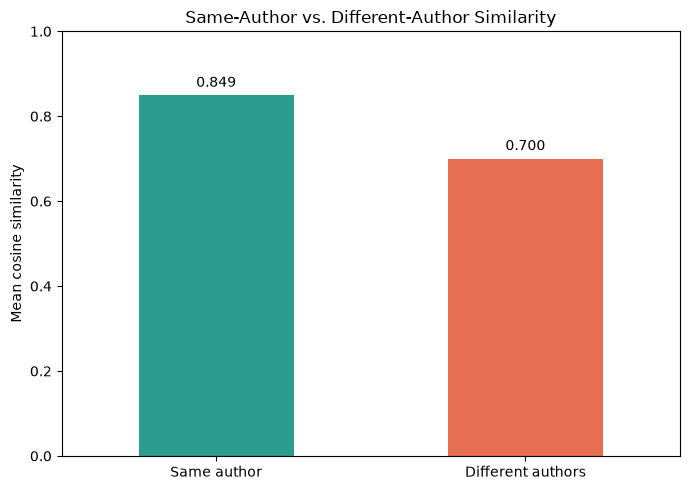

## Words used more frequently by Baum

,Baum per 10k,Carroll per 10k,log2 ratio
Word,,,
city,53.05,0.00,6.74
witch,44.80,0.00,6.50
emerald,38.75,0.00,6.29
brains,22.26,0.00,5.51
big,18.69,0.00,5.26
palace,17.86,0.00,5.20
straw,13.74,0.00,4.83
monkeys,12.92,0.00,4.75
axe,12.64,0.00,4.72


## Words used more frequently by Carroll

,Baum per 10k,Carroll per 10k,log2 ratio
Word,,,
talking,0.27,14.27,-4.25
song,0.00,8.97,-4.24
tea,0.27,10.60,-3.84
glass,0.82,16.71,-3.70
dream,0.27,8.97,-3.61
nobody,0.27,8.56,-3.55
let's,0.27,7.75,-3.41
hastily,0.55,9.38,-3.23
that's,3.02,32.21,-3.21


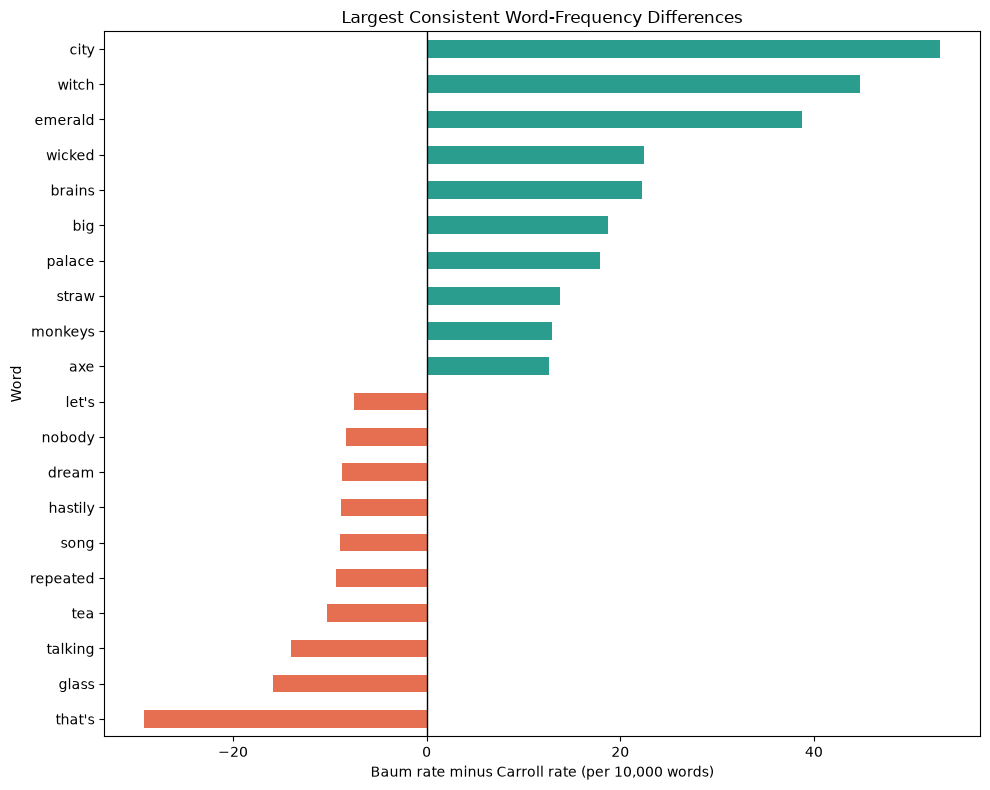


## What results did I get?

The two Baum books have a cosine similarity of **0.758**, and the two
Carroll books have a similarity of **0.941**. Mean same-author
similarity is **0.849**, compared with **0.700** for books by
different authors. For this sample, books by the same author therefore have more
similar word-frequency patterns.

Baum's strongest higher-frequency words include **city**, **witch**, **emerald**, **brains**, **big**. Carroll's include
**talking**, **song**, **tea**, **glass**, **dream**. Here, “preferred” means observed at a higher normalized frequency;
it does not prove conscious preference. Many differences may describe story content
as well as writing style.

## What problems did I encounter?

- Firstly, raw counts were inconsistent and misleading because the books have different lengths, so I used rates
  per 10,000 filtered words.
- Secondly, Project Gutenberg headers and footers had to be removed.
- Character names and common stop words could dominate the results as there would have been too many, so I filtered them.
- These books feature two different english styles, British versus American English, so that may affect the comparison.
- Two books per author is a relatively small sample, so this result and outcome should not be generalized to
  all authors or all fantasy books.

## What new ideas did this generate?

A future study could use more books and compare function words, sentence length,
punctuation, and parts of speech. A classifier could be trained on some books and then
tested on a different book by the same author. More genres could also help separate
author style from story topic.

## Conclusion

For these four fantasy books, within author word-frequency patterns were
more similar than cross author patterns. Distinct normalized vocabulary differences
also appeared between Baum and Carroll, although the small sample and story topics
limit the strength of the conclusion.


In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown, display
from nltk.corpus import stopwords

# Public-domain texts and authors
BOOKS = {
    "Wonderful Wizard of Oz": ("L. Frank Baum", "https://www.gutenberg.org/cache/epub/55/pg55.txt"),
    "Marvelous Land of Oz": ("L. Frank Baum", "https://www.gutenberg.org/cache/epub/54/pg54.txt"),
    "Alice in Wonderland": ("Lewis Carroll", "https://www.gutenberg.org/cache/epub/11/pg11.txt"),
    "Through the Looking-Glass": ("Lewis Carroll", "https://www.gutenberg.org/cache/epub/12/pg12.txt"),
}

try:
    STOP_WORDS = set(stopwords.words("english"))
except LookupError:
    import nltk
    nltk.download("stopwords", quiet=True)
    STOP_WORDS = set(stopwords.words("english"))

# Remove obvious character/title terms so plots are less dominated by story names.
NAMES = set("""
alice alice's baum bill boq carroll cat caterpillar cheshire dinah dorothy
dormouse dumpty duchess glinda gryphon gump hare hatter humpty jack king kitty
knight lion mombi mock oz pumpkinhead queen rabbit scarecrow tiktok tin tip toto
turtle tweedledee tweedledum unicorn wizard woggle woodman
""".split())

def remove_gutenberg_wrapper(text):
    start = re.search(r"\*\*\*\s*START OF (?:THE|THIS) PROJECT GUTENBERG EBOOK[^\n]*\*\*\*", text, re.I)
    if start:
        text = text[start.end():]
    end = re.search(r"\*\*\*\s*END OF (?:THE|THIS) PROJECT GUTENBERG EBOOK[^\n]*\*\*\*", text, re.I)
    return text[:end.start()] if end else text

def get_words(url):
    response = requests.get(url, timeout=30, headers={"User-Agent": "CS445 MiniProject1"})
    response.raise_for_status()
    text = remove_gutenberg_wrapper(response.content.decode("utf-8-sig", errors="replace"))
    text = text.lower().replace("’", "'").replace("‘", "'")
    all_words = re.findall(r"[a-z]+(?:'[a-z]+)?", text)
    filtered = [w for w in all_words if w not in STOP_WORDS and w not in NAMES and len(w) > 1]
    return all_words, filtered

all_tokens, filtered_tokens, counts = {}, {}, {}
for title, (author, url) in BOOKS.items():
    all_tokens[title], filtered_tokens[title] = get_words(url)
    counts[title] = Counter(filtered_tokens[title])

summary = pd.DataFrame({
    "Author": [BOOKS[t][0] for t in BOOKS],
    "Total words": [len(all_tokens[t]) for t in BOOKS],
    "Filtered words": [len(filtered_tokens[t]) for t in BOOKS],
    "Unique filtered words": [len(counts[t]) for t in BOOKS],
}, index=BOOKS)
summary.index.name = "Book"
display(Markdown("## Data check"))
display(summary)

# Assignment 1: compare word frequencies between two works of a single author.
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, title in zip(axes.flat, BOOKS):
    total = sum(counts[title].values())
    top = [(w, n / total * 10000) for w, n in counts[title].most_common(12)][::-1]
    ax.barh([x[0] for x in top], [x[1] for x in top],
            color="#2a9d8f" if BOOKS[title][0] == "L. Frank Baum" else "#e76f51")
    ax.set_title(f"{title}\n{BOOKS[title][0]}")
    ax.set_xlabel("Occurrences per 10,000 filtered words")
    ax.grid(axis="x", alpha=.25)
fig.suptitle("Most Frequent Words in Each Book", fontsize=17)
plt.tight_layout()
plt.show()

# Compare complete frequency patterns with cosine similarity.
titles = list(BOOKS)
vocabulary = sorted(set().union(*(counts[t] for t in titles)))
def cosine(a, b):
    va = np.array([a[w] for w in vocabulary], dtype=float)
    vb = np.array([b[w] for w in vocabulary], dtype=float)
    return float(np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb)))

similarity = pd.DataFrame([[cosine(counts[a], counts[b]) for b in titles]
                           for a in titles], index=titles, columns=titles)
display(Markdown("## Similarity of complete word-frequency patterns"))
display(similarity.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(similarity, cmap="Blues", vmin=0, vmax=1)
labels = ["Wizard of Oz", "Land of Oz", "Alice", "Looking-Glass"]
ax.set_xticks(range(4), labels, rotation=35, ha="right")
ax.set_yticks(range(4), labels)
for row in range(4):
    for col in range(4):
        ax.text(col, row, f"{similarity.iloc[row, col]:.3f}", ha="center", va="center",
                color="white" if similarity.iloc[row, col] > .78 else "black")
ax.set_title("Cosine Similarity of Word-Frequency Patterns")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

same_pairs = [(titles[0], titles[1]), (titles[2], titles[3])]
cross_pairs = [(a, b) for a in titles[:2] for b in titles[2:]]
same_values = [similarity.loc[a, b] for a, b in same_pairs]
cross_values = [similarity.loc[a, b] for a, b in cross_pairs]
same_mean, cross_mean = float(np.mean(same_values)), float(np.mean(cross_values))

comparison = pd.Series({"Same author": same_mean, "Different authors": cross_mean})
ax = comparison.plot.bar(figsize=(7, 5), color=["#2a9d8f", "#e76f51"], ylim=(0, 1))
ax.set_ylabel("Mean cosine similarity")
ax.set_title("Same-Author vs. Different-Author Similarity")
ax.tick_params(axis="x", rotation=0)
for i, value in enumerate(comparison):
    ax.text(i, value + .02, f"{value:.3f}", ha="center")
plt.tight_layout()
plt.show()

# Assignment 2 and 3: combine books by author and identify preferred words.
author_counts = {"L. Frank Baum": Counter(), "Lewis Carroll": Counter()}
for title, (author, url) in BOOKS.items():
    author_counts[author].update(counts[title])
author_totals = {author: sum(counter.values()) for author, counter in author_counts.items()}

rows = []
for word in set(author_counts["L. Frank Baum"]) | set(author_counts["Lewis Carroll"]):
    b = author_counts["L. Frank Baum"][word]
    c = author_counts["Lewis Carroll"][word]
    if b + c >= 20:
        br = b / author_totals["L. Frank Baum"] * 10000
        cr = c / author_totals["Lewis Carroll"] * 10000
        rows.append((word, br, cr, np.log2((br + .5) / (cr + .5))))
preference = pd.DataFrame(rows, columns=["Word", "Baum per 10k", "Carroll per 10k", "log2 ratio"]).set_index("Word")

baum_words = [w for w in preference.index if counts[titles[0]][w] >= 3 and counts[titles[1]][w] >= 3]
carroll_words = [w for w in preference.index if counts[titles[2]][w] >= 3 and counts[titles[3]][w] >= 3]
baum_top = preference.loc[baum_words].nlargest(10, "log2 ratio")
carroll_top = preference.loc[carroll_words].nsmallest(10, "log2 ratio")
display(Markdown("## Words used more frequently by Baum")); display(baum_top.round(2))
display(Markdown("## Words used more frequently by Carroll")); display(carroll_top.round(2))

selected = pd.concat([baum_top, carroll_top])
selected["difference"] = selected["Baum per 10k"] - selected["Carroll per 10k"]
selected = selected.sort_values("difference")
colors = ["#2a9d8f" if x > 0 else "#e76f51" for x in selected["difference"]]
ax = selected["difference"].plot.barh(figsize=(10, 8), color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Baum rate minus Carroll rate (per 10,000 words)")
ax.set_title("Largest Consistent Word-Frequency Differences")
plt.tight_layout()
plt.show()

baum_examples = ", ".join(f"**{w}**" for w in baum_top.index[:5])
carroll_examples = ", ".join(f"**{w}**" for w in carroll_top.index[:5])
display(Markdown(f"""
## What results did I get?

The two Baum books have a cosine similarity of **{same_values[0]:.3f}**, and the two
Carroll books have a similarity of **{same_values[1]:.3f}**. Mean same-author
similarity is **{same_mean:.3f}**, compared with **{cross_mean:.3f}** for books by
different authors. For this sample, books by the same author therefore have more
similar word-frequency patterns.

Baum's strongest higher-frequency words include {baum_examples}. Carroll's include
{carroll_examples}. Here, “preferred” means observed at a higher normalized frequency;
it does not prove conscious preference. Many differences may describe story content
as well as writing style.

## What problems did I encounter?

- Firstly, raw counts were inconsistent and misleading because the books have different lengths, so I used rates
  per 10,000 filtered words.
- Secondly, Project Gutenberg headers and footers had to be removed.
- Character names and common stop words could dominate the results as there would have been too many, so I filtered them.
- These books feature two different english styles, British versus American English, so that may affect the comparison.
- Two books per author is a relatively small sample, so this result and outcome should not be generalized to
  all authors or all fantasy books.

## What new ideas did this generate?

A future study could use more books and compare function words, sentence length,
punctuation, and parts of speech. A classifier could be trained on some books and then
tested on a different book by the same author. More genres could also help separate
author style from story topic.

## Conclusion

For these four fantasy books, within author word-frequency patterns were
more similar than cross author patterns. Distinct normalized vocabulary differences
also appeared between Baum and Carroll, although the small sample and story topics
limit the strength of the conclusion.
"""))